# M0 orientation EDA — DE-SynPUF

Quick orientation over the raw claims before any modeling: volume shapes, code long-tails, cost distribution, coverage, demographics. Detail plots use **sample 1** (a Task A eval sample — orientation only, no modeling decisions taken from it).

Caveat that applies to everything below: DE-SynPUF is *synthetic*. CMS's synthesis preserves marginals reasonably well but weakens cross-variable correlations, so absolute predictive signal will understate real claims data throughout this project.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
S1 = ROOT / "data/interim/synpuf/sample_01"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (8, 4)})

In [2]:
bene = {y: pl.read_parquet(S1 / f"beneficiary_{y}.parquet") for y in (2008, 2009, 2010)}
ip = pl.read_parquet(S1 / "inpatient.parquet")
op = pl.read_parquet(S1 / "outpatient.parquet")
rx = pl.read_parquet(S1 / "pde.parquet")

pl.DataFrame({
    "table": ["beneficiary 2008", "beneficiary 2009", "beneficiary 2010", "inpatient", "outpatient", "pde"],
    "rows": [bene[2008].height, bene[2009].height, bene[2010].height, ip.height, op.height, rx.height],
    "members": [df["DESYNPUF_ID"].n_unique() for df in (bene[2008], bene[2009], bene[2010], ip, op, rx)],
})

table,rows,members
str,i64,i64
"""beneficiary 2008""",116352,116352
"""beneficiary 2009""",114538,114538
"""beneficiary 2010""",112754,112754
"""inpatient""",66773,37780
"""outpatient""",790790,85272
"""pde""",5552421,99538


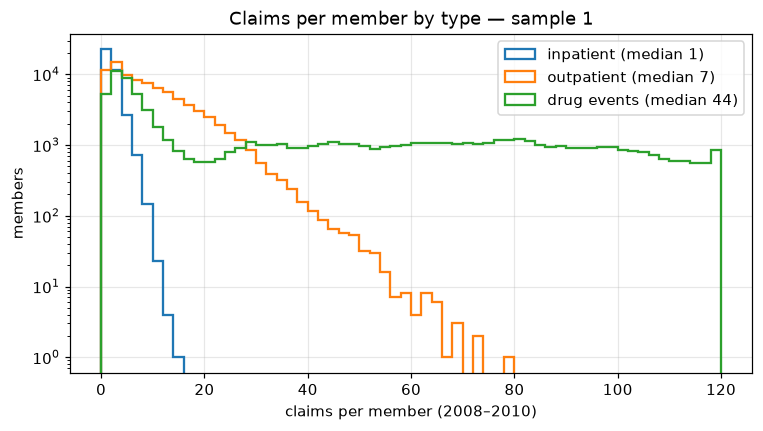

In [3]:
# 1. Claims per member, by claim type
fig, ax = plt.subplots()
for label, df in (("inpatient", ip), ("outpatient", op), ("drug events", rx)):
    n = df.group_by("DESYNPUF_ID").agg(pl.len().alias("n"))["n"]
    ax.hist(n, bins=range(0, 121, 2), histtype="step", lw=1.5, label=f"{label} (median {n.median():.0f})")
ax.set(yscale="log", xlabel="claims per member (2008\u20132010)", ylabel="members", title="Claims per member by type \u2014 sample 1")
ax.legend();

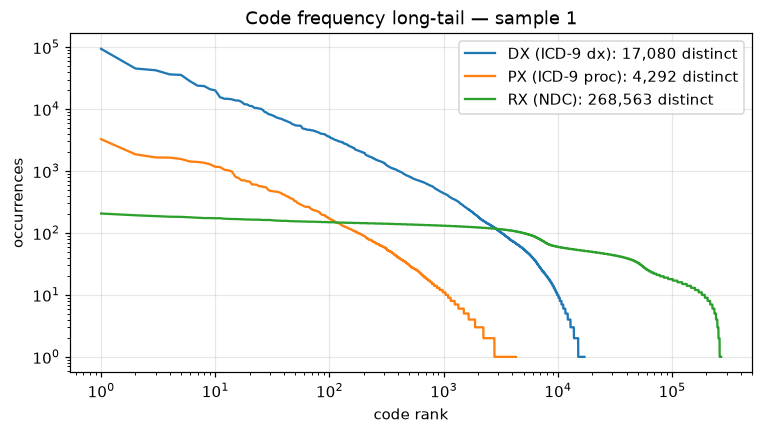

In [4]:
# 2. Code frequency long-tail, by code system (the vocabulary-design picture)
DX = [f"ICD9_DGNS_CD_{i}" for i in range(1, 11)]
PX = [f"ICD9_PRCDR_CD_{i}" for i in range(1, 7)]

def counts(df, cols):
    present = [c for c in cols if c in df.columns]
    return (df.select(present).unpivot(on=present)["value"].drop_nulls().value_counts(sort=True)["count"])

series = {
    "DX (ICD-9 dx)": pl.concat([counts(ip, DX), counts(op, DX)]).sort(descending=True),
    "PX (ICD-9 proc)": pl.concat([counts(ip, PX), counts(op, PX)]).sort(descending=True),
    "RX (NDC)": rx["PROD_SRVC_ID"].drop_nulls().value_counts(sort=True)["count"],
}
fig, ax = plt.subplots()
for label, s in series.items():
    ax.loglog(range(1, len(s) + 1), s, label=f"{label}: {len(s):,} distinct")
ax.set(xlabel="code rank", ylabel="occurrences", title="Code frequency long-tail \u2014 sample 1")
ax.legend();

zero-cost members: 26.2%; mean $4,917; p99 $60,184


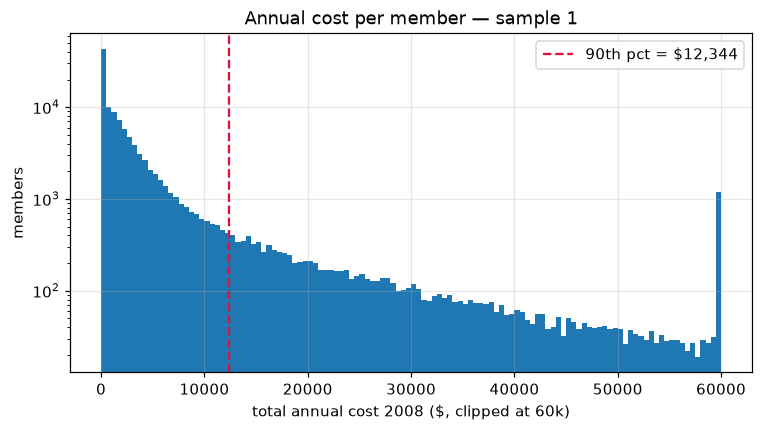

In [5]:
# 3. Annual total cost per member (2008) + top-decile threshold (the Task A label b shape)
cost_cols = [c for c in bene[2008].columns if c.startswith(("MEDREIMB_", "BENRES_", "PPPYMT_"))]
total = bene[2008].select(pl.sum_horizontal(cost_cols).alias("cost"))["cost"]
p90 = total.quantile(0.9)
fig, ax = plt.subplots()
ax.hist(total.clip(0, 60_000), bins=120)
ax.axvline(p90, color="crimson", ls="--", label=f"90th pct = ${p90:,.0f}")
ax.set(yscale="log", xlabel="total annual cost 2008 ($, clipped at 60k)", ylabel="members", title="Annual cost per member \u2014 sample 1")
ax.legend();
print(f"zero-cost members: {(total == 0).mean():.1%}; mean ${total.mean():,.0f}; p99 ${total.quantile(0.99):,.0f}")

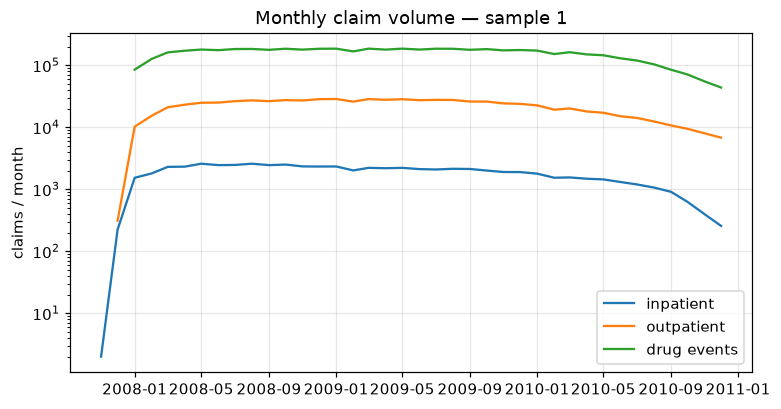

In [6]:
# 4. Monthly claim volume 2008-2010 (any truncation/ramp artifacts show up here)
fig, ax = plt.subplots()
for label, df, col in (("inpatient", ip, "CLM_ADMSN_DT"), ("outpatient", op, "CLM_FROM_DT"), ("drug events", rx, "SRVC_DT")):
    m = (df.select(pl.col(col).dt.truncate("1mo").alias("month")).drop_nulls()
           .group_by("month").agg(pl.len().alias("n")).sort("month"))
    ax.plot(m["month"], m["n"], label=label)
ax.set(yscale="log", ylabel="claims / month", title="Monthly claim volume \u2014 sample 1")
ax.legend();

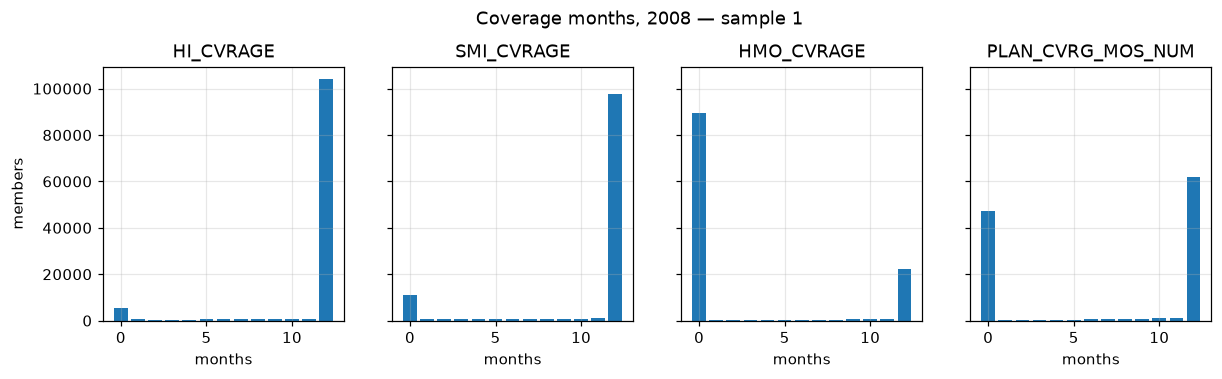

In [7]:
# 5. Coverage months (feeds the Task A cohort coverage rule)
cov_cols = ["BENE_HI_CVRAGE_TOT_MONS", "BENE_SMI_CVRAGE_TOT_MONS", "BENE_HMO_CVRAGE_TOT_MONS", "PLAN_CVRG_MOS_NUM"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharey=True)
for ax, c in zip(axes, cov_cols):
    vc = bene[2008][c].value_counts().sort(c)
    ax.bar(vc[c], vc["count"])
    ax.set(title=c.replace("BENE_", "").replace("_TOT_MONS", ""), xlabel="months")
axes[0].set_ylabel("members")
fig.suptitle("Coverage months, 2008 \u2014 sample 1", y=1.05);

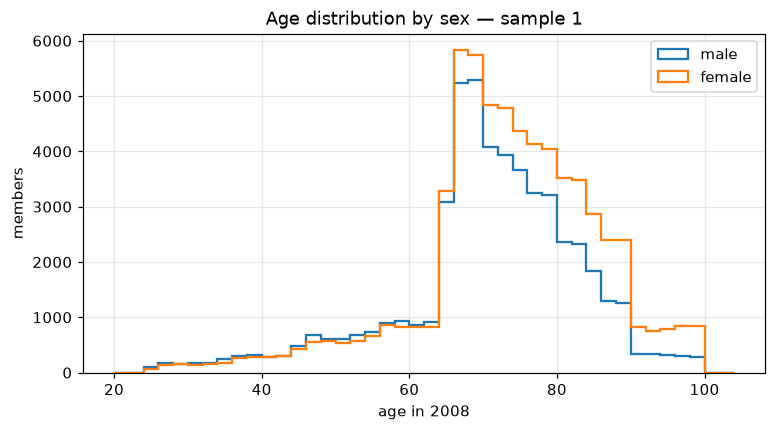

In [8]:
# 6. Age by sex (Medicare: 65+ dominant, disabled <65 minority; slices used in Task A equity analysis)
age = bene[2008].select(
    (2008 - pl.col("BENE_BIRTH_DT").dt.year()).alias("age"),
    pl.col("BENE_SEX_IDENT_CD").alias("sex"),
)
fig, ax = plt.subplots()
for code, label in (("1", "male"), ("2", "female")):
    ax.hist(age.filter(pl.col("sex") == code)["age"], bins=range(20, 105, 2), histtype="step", lw=1.5, label=label)
ax.set(xlabel="age in 2008", ylabel="members", title="Age distribution by sex \u2014 sample 1")
ax.legend();

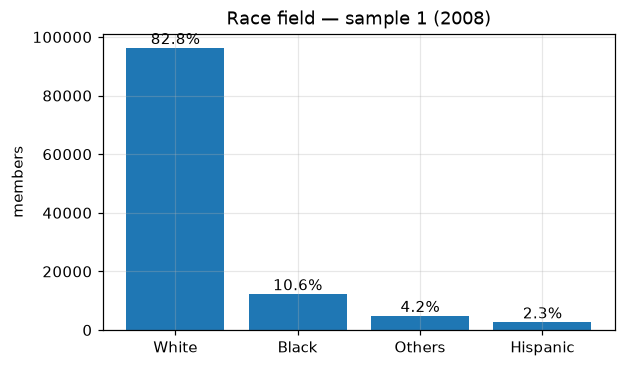

In [9]:
# 7. Race field (codebook: 1=White, 2=Black, 3=Others, 5=Hispanic) \u2014 basis for equity slices
race_names = {"1": "White", "2": "Black", "3": "Others", "5": "Hispanic"}
vc = bene[2008]["BENE_RACE_CD"].value_counts().sort("count", descending=True)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([race_names.get(v, v) for v in vc["BENE_RACE_CD"]], vc["count"])
for i, n in enumerate(vc["count"]):
    ax.annotate(f"{n / bene[2008].height:.1%}", (i, n), ha="center", va="bottom")
ax.set(ylabel="members", title="Race field \u2014 sample 1 (2008)");

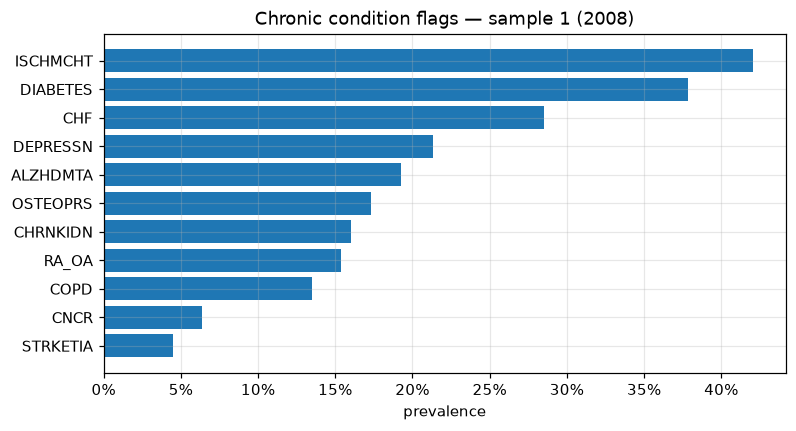

In [10]:
# 8. Chronic condition flag prevalence (SP_* fields; 1=yes 2=no per codebook)
sp_cols = [c for c in bene[2008].columns if c.startswith("SP_") and c != "SP_STATE_CODE"]
prev = sorted(((c.removeprefix("SP_"), (bene[2008][c] == "1").mean()) for c in sp_cols), key=lambda t: -t[1])
fig, ax = plt.subplots()
ax.barh([p[0] for p in prev][::-1], [p[1] for p in prev][::-1])
ax.set(xlabel="prevalence", title="Chronic condition flags \u2014 sample 1 (2008)")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}");

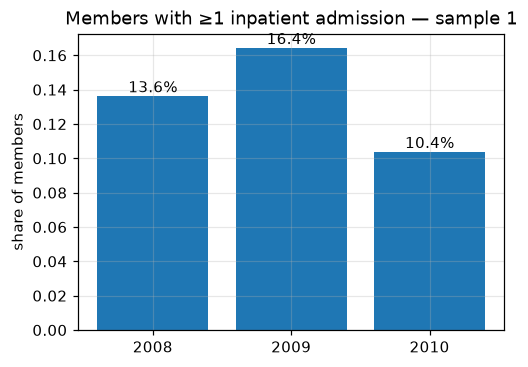

In [11]:
# 9. Task A label (a) base rate preview: members with >=1 inpatient admission per year
rates = {}
for y in (2008, 2009, 2010):
    admitted = ip.filter(pl.col("CLM_ADMSN_DT").dt.year() == y)["DESYNPUF_ID"].n_unique()
    rates[y] = admitted / bene[y].height
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar([str(y) for y in rates], list(rates.values()))
for i, v in enumerate(rates.values()):
    ax.annotate(f"{v:.1%}", (i, v), ha="center", va="bottom")
ax.set(ylabel="share of members", title="Members with \u22651 inpatient admission \u2014 sample 1");

## Notes for modeling

- **Long-tail vocabularies**: all three code systems are heavy-tailed; a frequency floor will retain the bulk of occurrences with a fraction of distinct codes (quantified at M1 in the vocab sweep).
- **Cost is zero-inflated and skewed** — the top-decile label is driven by a thin, expensive tail; calibration and lift@k will matter more than raw AUROC.
- **Inpatient admission runs ~14% of members per year here** (higher than typical commercial populations; this is an aged Medicare cohort) — AUPRC must be read against prevalence.
- **Coverage is mostly full-year**, so the Task A coverage rule will retain most members; exact cohort definition happens at M2.
- Synthetic-data caveat applies throughout (weakened code\u2013cost correlations).